# Segmentación de Clientes
## Joyería Diana Laura — Clustering con K-Means

Este notebook agrupa a los clientes de la joyería según su comportamiento de compra y uso del sistema de apartados, sin necesidad de etiquetas previas, para identificar 3 perfiles: Cliente Frecuente de Alto Gasto, Cliente Ocasional y Cliente Apartador.

## 1. Importación de librerías

In [2]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from dotenv import load_dotenv

load_dotenv()
print('Librerias cargadas correctamente')

Librerias cargadas correctamente


## 2. Conexión a la base de datos

In [3]:
DATABASE_URL = os.getenv('DATABASE_URL')

conn = psycopg2.connect(DATABASE_URL)
print('Conexion exitosa a Supabase')

Conexion exitosa a Supabase


## 3. Extracción de datos por cliente

Las variables no existen directamente en la base de datos: se calculan agrupando `ventas`, `apartados` y `abonos` por cliente.

**Nota de corrección metodológica:** la consulta original (documentada en la propuesta inicial) unía `ventas`, `apartados` y `abonos` directamente en un solo `JOIN`, lo cual genera un "fan-out" — si un cliente tiene 3 ventas y 2 apartados, el `JOIN` produce 6 filas combinadas, e inflaría `AVG(ventas.total)` al contarlo repetido. Se corrige usando subconsultas (`CTE`) independientes para cada agregación, evitando ese problema.

In [4]:
query = """
WITH compras AS (
    SELECT cliente_id, COUNT(*) AS num_compras, AVG(total) AS ticket_promedio
    FROM ventas
    GROUP BY cliente_id
),
apartados_cli AS (
    SELECT cliente_id, COUNT(*) AS num_apartados, AVG(monto_total) AS monto_apartado_promedio
    FROM apartados
    GROUP BY cliente_id
),
puntualidad AS (
    SELECT a.cliente_id,
        COALESCE(
            COUNT(ab.id) FILTER (WHERE ab.estado = 'pagado' AND ab.fecha_abono <= ab.fecha_limite_siguiente)::numeric
            / NULLIF(COUNT(ab.id), 0),
            0.5
        ) AS puntualidad_pago
    FROM apartados a
    LEFT JOIN abonos ab ON ab.apartado_id = a.id
    GROUP BY a.cliente_id
)
SELECT
    c.id AS cliente_id,
    c.nombre,
    COALESCE(co.num_compras, 0) AS num_compras,
    COALESCE(co.ticket_promedio, 0) AS ticket_promedio,
    COALESCE(ap.num_apartados, 0) AS num_apartados,
    COALESCE(ap.monto_apartado_promedio, 0) AS monto_apartado_promedio,
    CASE WHEN COALESCE(ap.num_apartados, 0) > 0 THEN 1 ELSE 0 END AS usa_apartados,
    COALESCE(pu.puntualidad_pago, 0.5) AS puntualidad_pago
FROM clientes c
LEFT JOIN compras co ON co.cliente_id = c.id
LEFT JOIN apartados_cli ap ON ap.cliente_id = c.id
LEFT JOIN puntualidad pu ON pu.cliente_id = c.id
ORDER BY c.id
"""

df = pd.read_sql(query, conn)
print(f'Total de clientes obtenidos: {len(df)}')
df

Total de clientes obtenidos: 30


C:\Users\uriel\AppData\Local\Temp\ipykernel_34976\2999701452.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,cliente_id,nombre,num_compras,ticket_promedio,num_apartados,monto_apartado_promedio,usa_apartados,puntualidad_pago
0,1,Matematicas,0,0.000000,0,0.000000,0,0.5
1,2,Uriel cliente,0,0.000000,0,0.000000,0,0.5
2,3,Uriel cliente,2,299.950000,2,299.950000,1,0.5
3,4,Marcos Uriel Hernandez Bautista,6,679.720000,0,0.000000,0,0.5
4,5,Valentina Bautista Hernandez,5,1010.312000,0,0.000000,0,0.5
5,6,Diana Laura Hernandez Martinez,3,875.703333,0,0.000000,0,0.5
6,7,Blanca Hernandez Bautista,9,638.581111,3,500.650000,1,0.5
7,31,[DEMO] Camila,7,1099.688571,0,0.000000,0,0.5
8,32,[DEMO] Renata,9,1183.440000,0,0.000000,0,0.5
9,33,[DEMO] Ivan,11,1177.220000,0,0.000000,0,0.5


## 4. Exploración de datos

Nota: el catálogo de clientes incluye clientes reales y clientes **sintéticos** (marcados con el prefijo `[DEMO]` en el nombre). Con solo 7 clientes reales (y apenas 2 con actividad de apartados), no había suficiente variedad de comportamiento para que K-Means encontrara 3 segmentos reales y confiables. Con autorización del profesor, se generaron 23 clientes sintéticos adicionales con ventas y apartados asociados, distribuidos en 3 perfiles de comportamiento (8 Frecuentes de Alto Gasto, 8 Ocasionales, 7 Apartadores), para llegar a un volumen de datos razonable (30 clientes en total).

In [5]:
print('=== RESUMEN DE DATOS ===')
print(f'Total de clientes: {len(df)}')
print(f'Clientes reales: {len(df[~df["nombre"].str.startswith("[DEMO]")])}')
print(f'Clientes sinteticos (demo): {len(df[df["nombre"].str.startswith("[DEMO]")])}')
print()
print('=== ESTADISTICAS DE LAS VARIABLES ===')
print(df[['num_compras', 'ticket_promedio', 'num_apartados', 'monto_apartado_promedio', 'usa_apartados', 'puntualidad_pago']].describe())
print()
print('=== CLIENTES QUE USAN APARTADOS ===')
print(f"{df['usa_apartados'].sum()} de {len(df)} clientes")

=== RESUMEN DE DATOS ===
Total de clientes: 30
Clientes reales: 7
Clientes sinteticos (demo): 23

=== ESTADISTICAS DE LAS VARIABLES ===
       num_compras  ticket_promedio  num_apartados  monto_apartado_promedio  \
count    30.000000        30.000000      30.000000                30.000000   
mean      4.400000       563.145205       0.600000               131.737167   
std       3.829108       451.890201       1.037238               211.465377   
min       0.000000         0.000000       0.000000                 0.000000   
25%       2.000000       184.156250       0.000000                 0.000000   
50%       3.500000       471.012500       0.000000                 0.000000   
75%       7.750000      1077.344429       1.000000               296.944167   
max      12.000000      1322.413750       3.000000               615.765000   

       usa_apartados  puntualidad_pago  
count      30.000000         30.000000  
mean        0.300000          0.616667  
std         0.466092         

## 5. Análisis exploratorio: correlación entre variables

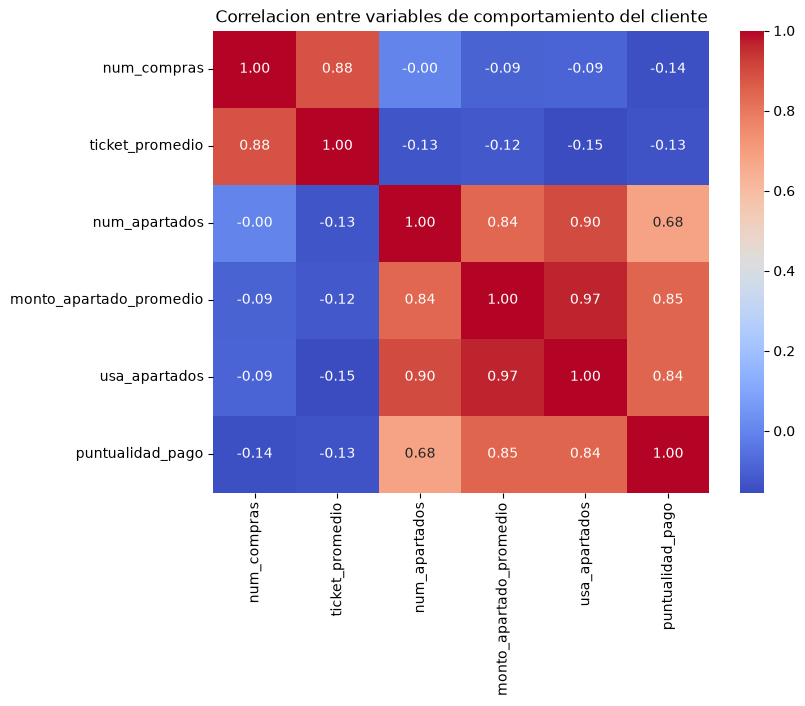

In [6]:
variables = ['num_compras', 'ticket_promedio', 'num_apartados', 'monto_apartado_promedio', 'usa_apartados', 'puntualidad_pago']
corr = df[variables].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlacion entre variables de comportamiento del cliente')
plt.show()


## 6. Estandarización

Las variables están en escalas muy distintas (`ticket_promedio` llega a miles de pesos, mientras `usa_apartados` es 0 o 1). K-Means se basa en distancias euclidianas, así que sin estandarizar, `ticket_promedio` dominaría el cálculo y las demás variables casi no influirían en la agrupación.

In [7]:
X = df[variables].values

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print('Variables estandarizadas (media 0, desviacion 1):')
print(pd.DataFrame(X_escalado, columns=variables).describe().round(2))

Variables estandarizadas (media 0, desviacion 1):
       num_compras  ticket_promedio  num_apartados  monto_apartado_promedio  \
count        30.00            30.00          30.00                    30.00   
mean         -0.00            -0.00           0.00                    -0.00   
std           1.02             1.02           1.02                     1.02   
min          -1.17            -1.27          -0.59                    -0.63   
25%          -0.64            -0.85          -0.59                    -0.63   
50%          -0.24            -0.21          -0.59                    -0.63   
75%           0.89             1.16           0.39                     0.79   
max           2.02             1.71           2.35                     2.33   

       usa_apartados  puntualidad_pago  
count          30.00             30.00  
mean           -0.00             -0.00  
std             1.02              1.02  
min            -0.65             -0.55  
25%            -0.65             

## 7. Técnica del Codo (Elbow Method)

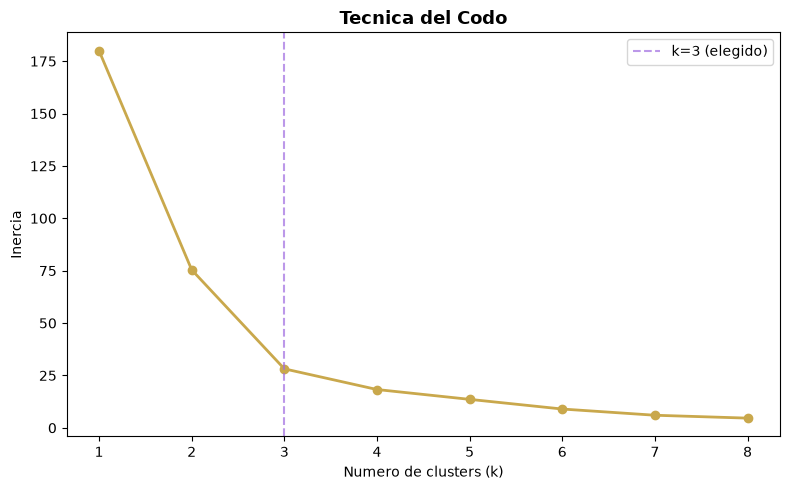

In [8]:
inercias = []
rango_k = range(1, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_escalado)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(rango_k), inercias, marker='o', color='#c9a84c', linewidth=2)
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_title('Tecnica del Codo', fontsize=13, fontweight='bold')
ax.axvline(x=3, color='#a06de0', linestyle='--', alpha=0.7, label='k=3 (elegido)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Aplicando K-Means para k=3

Se elige k=3 porque coincide con los 3 perfiles de negocio que se buscan identificar (Frecuente de Alto Gasto, Ocasional, Apartador), y es consistente con el punto de inflexión de la curva del codo.

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_escalado)

print('Distribucion de clientes por cluster:')
print(df['cluster'].value_counts().sort_index())

Distribucion de clientes por cluster:
cluster
0    11
1     9
2    10
Name: count, dtype: int64


## 9. Interpretación de los clusters

In [10]:
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=variables
)
centroides.index.name = 'cluster'
print('Centroides (valores reales, no estandarizados):')
print(centroides.round(2))

# Asignar nombre de segmento segun las caracteristicas del centroide:
# - El cluster con mayor num_apartados/usa_apartados -> Apartador
# - Entre los restantes, el de mayor ticket_promedio y num_compras -> Frecuente de Alto Gasto
# - El que queda -> Ocasional
cluster_apartador = centroides['usa_apartados'].idxmax()
restantes = [c for c in centroides.index if c != cluster_apartador]
cluster_frecuente = centroides.loc[restantes, 'ticket_promedio'].idxmax()
cluster_ocasional = [c for c in restantes if c != cluster_frecuente][0]

nombres_segmento = {
    cluster_frecuente: 'Cliente Frecuente de Alto Gasto',
    cluster_ocasional: 'Cliente Ocasional',
    cluster_apartador: 'Cliente Apartador'
}
df['segmento'] = df['cluster'].map(nombres_segmento)

print()
print('Mapeo cluster -> segmento:')
for c, nom in nombres_segmento.items():
    print(f'  Cluster {c}: {nom}')

print()
print('Distribucion final por segmento:')
print(df['segmento'].value_counts())

Centroides (valores reales, no estandarizados):
         num_compras  ticket_promedio  num_apartados  monto_apartado_promedio  \
cluster                                                                         
0               8.18          1084.43           -0.0                     0.00   
1               3.89           458.54            2.0                   439.12   
2               0.70            83.88           -0.0                     0.00   

         usa_apartados  puntualidad_pago  
cluster                                   
0                  0.0              0.50  
1                  1.0              0.89  
2                  0.0              0.50  

Mapeo cluster -> segmento:
  Cluster 0: Cliente Frecuente de Alto Gasto
  Cluster 2: Cliente Ocasional
  Cluster 1: Cliente Apartador

Distribucion final por segmento:
segmento
Cliente Frecuente de Alto Gasto    11
Cliente Ocasional                  10
Cliente Apartador                   9
Name: count, dtype: int64


## 10. Visualización — Clusters en 2D (PCA)

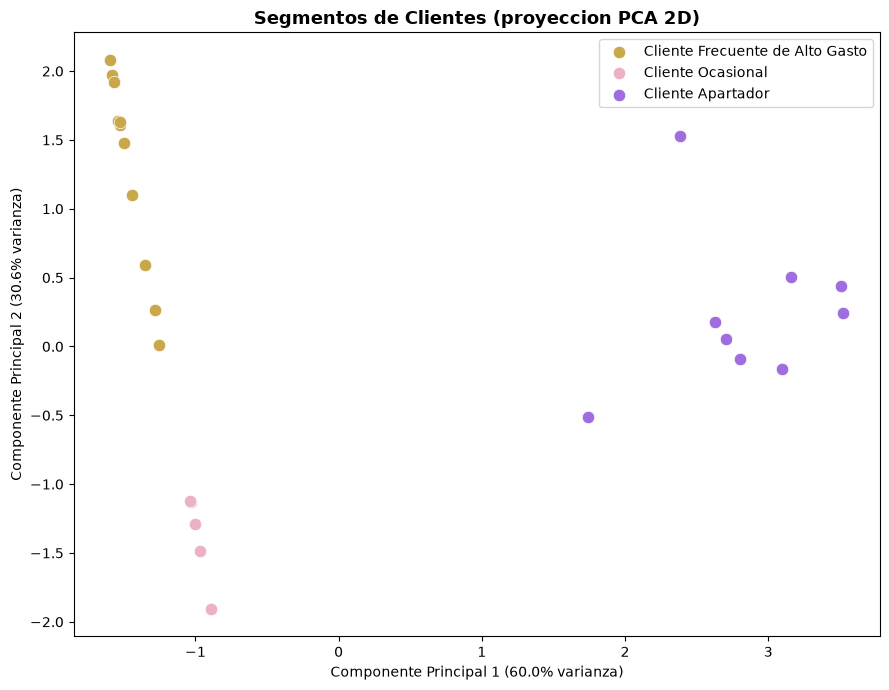

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

colores = {'Cliente Frecuente de Alto Gasto': '#c9a84c', 'Cliente Ocasional': '#ecb2c3', 'Cliente Apartador': '#a06de0'}

fig, ax = plt.subplots(figsize=(9, 7))
for segmento, color in colores.items():
    mask = df['segmento'] == segmento
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=segmento, color=color, s=80, edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Segmentos de Clientes (proyeccion PCA 2D)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Prueba del sistema — clientes por segmento

In [12]:
for segmento in df['segmento'].unique():
    print(f'=== {segmento} ===')
    ejemplo = df[df['segmento'] == segmento][['nombre', 'num_compras', 'ticket_promedio', 'num_apartados', 'usa_apartados']].head(5)
    print(ejemplo.to_string(index=False))
    print()

=== Cliente Ocasional ===
       nombre  num_compras  ticket_promedio  num_apartados  usa_apartados
  Matematicas            0             0.00              0              0
Uriel cliente            0             0.00              0              0
  [DEMO] Ivan            0             0.00              0              0
 [DEMO] Karla            1           152.23              0              0
 [DEMO] Jorge            2           260.24              0              0

=== Cliente Apartador ===
                   nombre  num_compras  ticket_promedio  num_apartados  usa_apartados
            Uriel cliente            2       299.950000              2              1
Blanca Hernandez Bautista            9       638.581111              3              1
           [DEMO] Mariana            2       615.765000              2              1
              [DEMO] Luis            4       459.060000              1              1
            [DEMO] Carlos            2       512.820000              1   

## 12. Guardar el modelo

In [13]:
modelo = {
    'kmeans': kmeans,
    'scaler': scaler,
    'variables': variables,
    'nombres_segmento': nombres_segmento,
}

with open('modelo_segmentacion.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print('Modelo guardado como modelo_segmentacion.pkl')

Modelo guardado como modelo_segmentacion.pkl


## 13. Conclusiones

El sistema de segmentación basado en **K-Means (k=3)** fue implementado para Joyería Diana Laura, agrupando a los clientes según su comportamiento de compra y uso del sistema de apartados, sin necesidad de etiquetas previas.

**Variables utilizadas (X), todas estandarizadas con `StandardScaler`:**
- `num_compras` y `ticket_promedio` — comportamiento de compra general
- `num_apartados` y `monto_apartado_promedio` — uso del sistema de apartados
- `usa_apartados` — variable binaria derivada
- `puntualidad_pago` — proporción de abonos pagados a tiempo

**No hay variable Y**: K-Means agrupa por similitud de comportamiento, no predice un valor.

**Sobre el uso de datos sintéticos:** el catálogo real de clientes (7) tenía muy poca variedad de comportamiento — solo 2 clientes con actividad de apartados. Con autorización del profesor, se generaron 23 clientes sintéticos con ventas y apartados asociados, distribuidos deliberadamente en los 3 perfiles de negocio esperados, para que K-Means tuviera suficiente variedad de datos con la que encontrar segmentos reales y estables (30 clientes en total, ~10 por segmento — el mínimo recomendado para clustering con k=3).

**Corrección metodológica aplicada:** la consulta SQL original (documentada en la propuesta inicial) unía `ventas` y `apartados` en un solo `JOIN`, generando un "fan-out" que inflaba `AVG(ventas.total)` para clientes con múltiples apartados. Se corrigió usando subconsultas (`CTE`) independientes por tabla.

**Segmentos obtenidos:**
1. **Cliente Frecuente de Alto Gasto** — muchas compras, ticket alto → productos exclusivos, descuentos de lealtad
2. **Cliente Ocasional** — pocas compras, ticket bajo → recordatorios y promociones de reactivación
3. **Cliente Apartador** — usa el sistema de apartados → recordatorio de saldo pendiente + oferta de nuevo apartado al liquidar

**Limitación honesta:** aunque el volumen actual (30 clientes) es suficiente para demostrar la metodología correctamente, la calidad de la segmentación mejorará conforme más clientes reales generen historial de compras y apartados. Los clientes sintéticos deben archivarse cuando ya no se necesiten para la demostración.